# 🔐 Data Preprocessing for Network Intrusion Detection

Ce notebook présente les différentes étapes de prétraitement des données utilisées dans le projet de détection d’intrusion réseau basé sur le Machine Learning et le Deep Learning.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 📦 Importation des bibliothèques

In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

## 📂 Chargement des données

In [ ]:
train_df = pd.read_csv('/content/drive/My Drive/network-intrusion-detection-ml/dataset/train_df.csv')
test_df = pd.read_csv('/content/drive/My Drive/network-intrusion-detection-ml/dataset/test_df.csv')

/tmp/ipykernel_11691/3184705483.py:2: DtypeWarning: Columns (79) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv('/content/drive/My Drive/network-intrusion-detection-ml/dataset/train_df.csv')


In [ ]:
print(train_df.shape)
print(test_df.shape)

(440000, 82)
(137860, 88)


## 🔍 Vérification de cohérence des datasets

In [ ]:
# Remove leading and trailing spaces from column names
train_df.columns = train_df.columns.str.strip()
test_df.columns = test_df.columns.str.strip()

# Identify columns present in test set but absent in training set
extra_cols_in_test = set(test_df.columns) - set(train_df.columns)

print("Extra columns found in test dataset:")
print(extra_cols_in_test)

# Remove extra columns from test dataset
test_df.drop(columns=extra_cols_in_test, inplace=True)

print(f"{len(extra_cols_in_test)} extra columns removed from test dataset.")

# Verify that train and test datasets now share identical columns
print("Datasets aligned successfully:",
      all(train_df.columns == test_df.columns))

Extra columns found in test dataset:
{'Timestamp', 'Destination IP', 'Destination Port', 'Source IP', 'Source Port', 'Flow ID'}
6 extra columns removed from test dataset.
Datasets aligned successfully: True


In [ ]:
train_df.shape, test_df.shape

((440000, 82), (137860, 82))

## 🧼 Nettoyage des données

Cette section supprime :
- les colonnes inutiles ou redondantes
- les valeurs infinies et manquantes
- les lignes dupliquées

afin d'améliorer la qualité des données avant l'entraînement des modèles.

### 🔹 Suppression des caractéristiques inutiles ou redondantes

Certaines caractéristiques du dataset ont été supprimées avant l’entraînement des modèles pour plusieurs raisons :

- présence de valeurs constantes ou quasi nulles
- caractéristiques redondantes
- absence de contribution significative à la classification
- colonnes techniques ou inutiles pour le Machine Learning
- réduction du bruit et de la complexité des données

#### 📌 Colonnes supprimées

| Catégorie | Colonnes | Raison |
|---|---|---|
| TCP Flags peu informatifs | `Bwd PSH Flags`, `Fwd URG Flags`, `Bwd URG Flags`, `FIN Flag Count`, `PSH Flag Count`, `ECE Flag Count` | Faible variance ou faible contribution à la classification |
| Features Bulk redondantes | `Fwd Avg Bytes/Bulk`, `Fwd Avg Packets/Bulk`, `Fwd Avg Bulk Rate`, `Bwd Avg Bytes/Bulk`, `Bwd Avg Packets/Bulk`, `Bwd Avg Bulk Rate` | Données redondantes et peu discriminantes |
| Colonne technique | `Unnamed: 0` | Index inutile généré automatiquement |
| Donnée peu exploitable | `SimillarHTTP` | Trop de valeurs manquantes ou faible pertinence |

In [ ]:
# List of unnecessary or redundant features
unwanted = [
    'Bwd PSH Flags',
    'Fwd URG Flags',
    'Bwd URG Flags',
    'FIN Flag Count',
    'PSH Flag Count',
    'ECE Flag Count',
    'Fwd Avg Bytes/Bulk',
    'Fwd Avg Packets/Bulk',
    'Fwd Avg Bulk Rate',
    'Bwd Avg Bytes/Bulk',
    'Bwd Avg Packets/Bulk',
    'Bwd Avg Bulk Rate',
    'Unnamed: 0',
    'SimillarHTTP'
]

# Remove unwanted columns
train_df.drop(columns=unwanted, inplace=True, errors='ignore')
test_df.drop(columns=unwanted, inplace=True, errors='ignore')

print(f"{len(unwanted)} unnecessary columns removed.")

14 unnecessary columns removed.


### 🔹 Gestion des valeurs manquantes et infinies

In [ ]:
# Replace infinite values with NaN
train_df.replace([np.inf, -np.inf], np.nan, inplace=True)
test_df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Count missing values
print("Missing values in train dataset:",
      train_df.isnull().sum().sum())

print("Missing values in test dataset:",
      test_df.isnull().sum().sum())

# Remove rows containing missing values
train_df.dropna(inplace=True)
test_df.dropna(inplace=True)

print("Missing values removed successfully.")

Missing values in train dataset: 27338
Missing values in test dataset: 9884
Missing values removed successfully.


### 🔹 Suppression des doublons

In [ ]:
# Count duplicate rows
print("Duplicate rows in train dataset:",
      train_df.duplicated().sum())

print("Duplicate rows in test dataset:",
      test_df.duplicated().sum())

# Remove duplicate rows
train_df.drop_duplicates(inplace=True)
test_df.drop_duplicates(inplace=True)

print("Duplicate rows removed successfully.")

Duplicate rows in train dataset: 290758
Duplicate rows in test dataset: 91854
Duplicate rows removed successfully.


In [ ]:
train_df.shape, test_df.shape

((135573, 68), (41064, 68))

## 📊 Analyse et traitement des caractéristiques

Cette section permet :
- d’identifier les colonnes redondantes
- de détecter les caractéristiques dupliquées
- d’analyser les types de variables
- d’améliorer la qualité des données avant l’entraînement des modèles

### 🔹 Suppression des colonnes redondantes

In [ ]:
def drop_redundant_columns(df):
    """
    Remove manually identified redundant columns.
    """
    redundant_columns = ['Fwd Header Length.1']

    df.drop(columns=redundant_columns,
            inplace=True,
            errors='ignore')

    return df


# Apply to datasets
drop_redundant_columns(train_df)
drop_redundant_columns(test_df)

print("Datasets shape after redundant column removal:")
print(train_df.shape, test_df.shape)

Datasets shape after redundant column removal:
(135573, 67) (41064, 67)


### 🔹 Détection des colonnes dupliquées

In [ ]:
def detect_duplicate_columns(df):
    """
    Detect columns containing identical values.
    """
    duplicate_columns = []
    columns = df.columns

    for i in range(len(columns)):
        for j in range(i + 1, len(columns)):

            col1 = columns[i]
            col2 = columns[j]

            if df[col1].equals(df[col2]):
                duplicate_columns.append((col1, col2))

    return duplicate_columns

### 🔹 Suppression des colonnes dupliquées

In [ ]:
# Detect duplicate columns in training dataset
duplicate_columns_train = detect_duplicate_columns(train_df)

if duplicate_columns_train:

    print("Duplicate columns detected in training dataset:")

    for original, duplicate in duplicate_columns_train:

        print(f"{duplicate} is a duplicate of {original}")

        train_df.drop(columns=[duplicate],
                      inplace=True)

else:
    print("No duplicate columns detected in training dataset.")


# Detect duplicate columns in test dataset
duplicate_columns_test = detect_duplicate_columns(test_df)

if duplicate_columns_test:

    print("Duplicate columns detected in test dataset:")

    for original, duplicate in duplicate_columns_test:

        print(f"{duplicate} is a duplicate of {original}")

        test_df.drop(columns=[duplicate],
                     inplace=True)

else:
    print("No duplicate columns detected in test dataset.")

Duplicate columns detected in training dataset:
Subflow Fwd Packets is a duplicate of Total Fwd Packets
Subflow Bwd Packets is a duplicate of Total Backward Packets
RST Flag Count is a duplicate of Fwd PSH Flags
Duplicate columns detected in test dataset:
Subflow Fwd Packets is a duplicate of Total Fwd Packets
Subflow Bwd Packets is a duplicate of Total Backward Packets
RST Flag Count is a duplicate of Fwd PSH Flags


### 🔹 Analyse des types de variables

In [ ]:
def grab_col_names(data,
                   cat_th=10,
                   car_th=20):
    """
    Identify categorical, numerical and high-cardinality columns.
    """

    # Categorical columns
    cat_cols = [
        col for col in data.columns
        if data[col].dtypes == "O"
    ]

    # Numerical but categorical
    num_but_cat = [
        col for col in data.columns
        if data[col].nunique() < cat_th
        and data[col].dtypes != "O"
    ]

    # High cardinality categorical columns
    high_card_cat_cols = [
        col for col in data.columns
        if data[col].nunique() > car_th
        and data[col].dtypes == "O"
    ]

    # Final categorical columns
    cat_cols = cat_cols + num_but_cat
    cat_cols = [
        col for col in cat_cols
        if col not in high_card_cat_cols
    ]

    # Numerical columns
    num_cols = [
        col for col in data.columns
        if data[col].dtypes != "O"
    ]

    num_cols = [
        col for col in num_cols
        if col not in num_but_cat
    ]

    print(f"Observations: {data.shape[0]}")
    print(f"Variables: {data.shape[1]}")
    print(f"Categorical Columns: {len(cat_cols)}")
    print(f"Numerical Columns: {len(num_cols)}")
    print(f"High Cardinality Columns: {len(high_card_cat_cols)}")
    print(f"Numerical but Categorical: {len(num_but_cat)}")

    return cat_cols, num_cols, high_card_cat_cols

### 🔹 Résumé des caractéristiques

In [ ]:
cat_cols, num_cols, high_card_cat_cols = grab_col_names(train_df)

print("\nCategorical Columns:")
print(cat_cols)

print("\nNumerical Columns:")
print(num_cols)

print("\nHigh Cardinality Columns:")
print(high_card_cat_cols)

Observations: 135573
Variables: 64
Categorical Columns: 8
Numerical Columns: 56
High Cardinality Columns: 0
Numerical but Categorical: 7

Categorical Columns:
['Label', 'Protocol', 'Fwd PSH Flags', 'SYN Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'Inbound']

Numerical Columns:
['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length

### 🔹 Analyse des corrélations entre caractéristiques

Cette étape identifie les variables fortement corrélées afin de réduire la redondance des données et d'améliorer la qualité des caractéristiques utilisées pour l'entraînement des modèles.

Les colonnes présentant une corrélation supérieure à 0.8 sont supprimées.

In [ ]:
def remove_highly_correlated_features(df,
                                      threshold=0.8):
    """
    Detect and remove highly correlated numerical features.
    """

    # Select only numerical columns
    numerical_df = df.select_dtypes(include=[np.number])

    # Compute absolute correlation matrix
    corr_matrix = numerical_df.corr().abs()

    # Keep only upper triangle of correlation matrix
    upper_triangle = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape),
                k=1).astype(bool)
    )

    # Identify highly correlated columns
    high_corr_cols = [
        col for col in upper_triangle.columns
        if any(upper_triangle[col] > threshold)
    ]

    print(f"Highly correlated columns detected: {len(high_corr_cols)}")
    print(high_corr_cols)

    # Remove correlated columns
    df.drop(columns=high_corr_cols,
            inplace=True)

    return high_corr_cols

In [ ]:
# Remove highly correlated columns from training dataset
high_corr_cols = remove_highly_correlated_features(
    train_df,
    threshold=0.8
)

# Remove the same columns from test dataset
test_df.drop(columns=high_corr_cols,
             inplace=True,
             errors='ignore')

print("Highly correlated features removed successfully.")

Highly correlated columns detected: 36
['Total Length of Bwd Packets', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Bwd Packet Length Max', 'Bwd Packet Length Std', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Std', 'Bwd IAT Max', 'Fwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'ACK Flag Count', 'CWE Flag Count', 'Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Subflow Fwd Bytes', 'Subflow Bwd Bytes', 'act_data_pkt_fwd', 'Active Max', 'Active Min', 'Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min']
Highly correlated features removed successfully.


In [ ]:
print(train_df.shape)
print(test_df.shape)

(135573, 28)
(41064, 28)


In [ ]:
# Select only numerical columns
numerical_df = train_df.select_dtypes(include=[np.number])

# Compute correlation matrix
corr_matrix = numerical_df.corr().abs()

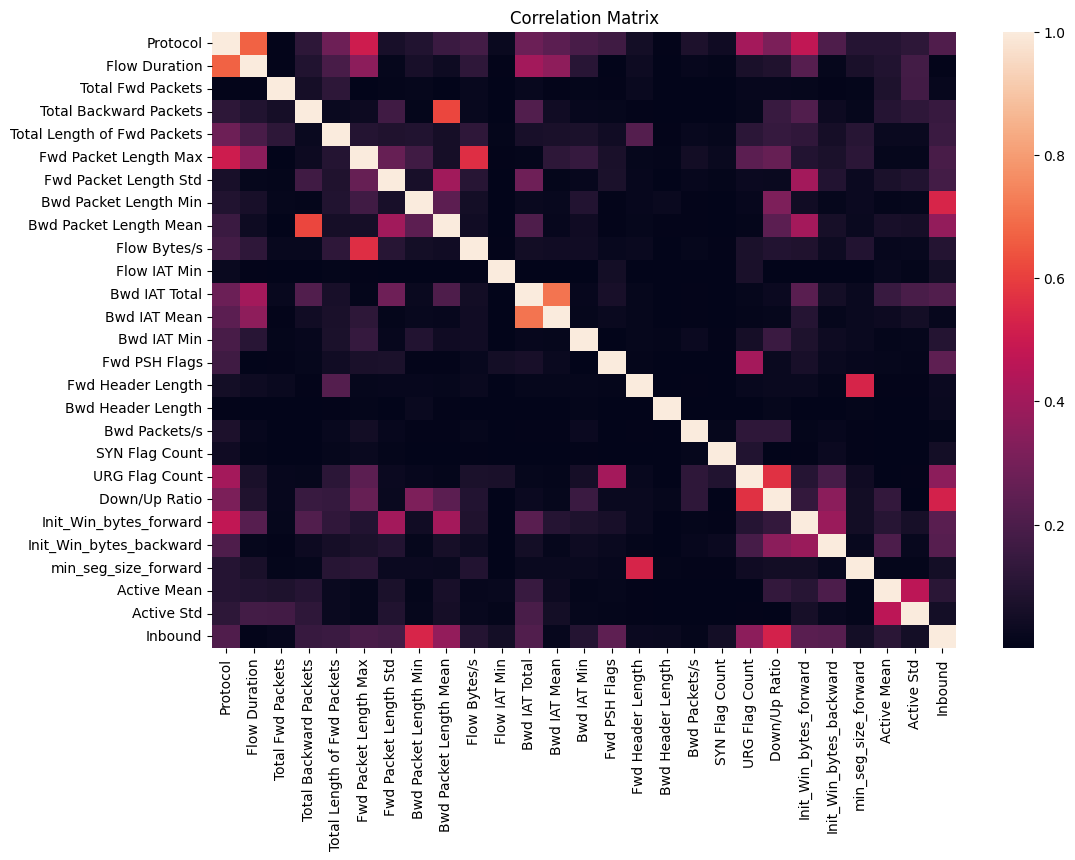

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix)
plt.title("Correlation Matrix")
plt.show()

## 🏷️ Préparation et harmonisation des labels

Cette étape permet d’uniformiser les noms des classes entre les datasets d’entraînement et de test afin d’assurer une cohérence lors de l’entraînement et de l’évaluation des modèles.

### 🔹 Harmonisation des classes

In [ ]:
# Mapping labels to a unified format
label_mapping = {
    'UDP': 'DrDoS_UDP',
    'UDPLag': 'UDP-lag',
    'MSSQL': 'DrDoS_MSSQL',
    'LDAP': 'DrDoS_LDAP',
    'NetBIOS': 'DrDoS_NetBIOS',
    'Syn': 'Syn',
    'BENIGN': 'BENIGN'
}

# Replace labels safely
test_df["Label"] = test_df["Label"].replace(label_mapping)

# Verify labels after mapping
print(test_df["Label"].unique())

['DrDoS_NetBIOS' 'Portmap' 'Syn' 'BENIGN' 'DrDoS_LDAP' 'DrDoS_UDP'
 'DrDoS_MSSQL' 'UDP-lag']


In [ ]:
print(test_df["Label"].isna().sum())

0


### 🔹 Définition des classes finales

In [ ]:
# Final target classes used for classification
classes_7 = [
    'BENIGN',
    'DrDoS_UDP',
    'UDP-lag',
    'DrDoS_MSSQL',
    'DrDoS_LDAP',
    'DrDoS_NetBIOS',
    'Syn'
]

print("Selected classes:")
print(classes_7)

Selected classes:
['BENIGN', 'DrDoS_UDP', 'UDP-lag', 'DrDoS_MSSQL', 'DrDoS_LDAP', 'DrDoS_NetBIOS', 'Syn']


### 🔹 Vérification des labels

In [ ]:
# Check unique labels after mapping
print("Unique labels in training dataset:")
print(train_df["Label"].unique())

print("\nUnique labels in test dataset:")
print(test_df["Label"].unique())

Unique labels in training dataset:
['DrDoS_DNS' 'BENIGN' 'DrDoS_LDAP' 'DrDoS_MSSQL' 'DrDoS_NetBIOS'
 'DrDoS_NTP' 'DrDoS_SNMP' 'DrDoS_SSDP' 'Syn' 'TFTP' 'DrDoS_UDP' 'UDP-lag'
 'WebDDoS']

Unique labels in test dataset:
['DrDoS_NetBIOS' 'Portmap' 'Syn' 'BENIGN' 'DrDoS_LDAP' 'DrDoS_UDP'
 'DrDoS_MSSQL' 'UDP-lag']


## 📦 Génération des datasets finaux

Cette étape construit les datasets finaux utilisés pour l'entraînement et l'évaluation des modèles de Machine Learning et Deep Learning.

Seules les classes sélectionnées pour le problème de classification sont conservées.

In [ ]:
# Display labels excluded from final classification
excluded_labels = set(test_df["Label"].unique()) - set(classes_7)

print("Excluded labels:")
print(excluded_labels)

Excluded labels:
{'Portmap'}


### 🔹 Filtrage des classes sélectionnées

In [ ]:
# Create training dataset with selected classes
train_7_classes = train_df[
    train_df['Label'].isin(classes_7)
].copy()

# Create test dataset with selected classes
test_7_classes = test_df[
    test_df['Label'].isin(classes_7)
].copy()

print("Datasets generated successfully.")

Datasets generated successfully.


### 🔹 Distribution des classes

In [ ]:
print("Training dataset class distribution:")
print(train_7_classes['Label'].value_counts())

print("\nTest dataset class distribution:")
print(test_7_classes['Label'].value_counts())

Training dataset class distribution:
Label
UDP-lag          19541
DrDoS_UDP        18523
Syn              16178
BENIGN           13960
DrDoS_NetBIOS     6855
DrDoS_MSSQL       4685
DrDoS_LDAP        1848
Name: count, dtype: int64

Test dataset class distribution:
Label
Syn              17297
BENIGN           10873
DrDoS_UDP         8602
DrDoS_MSSQL       1860
DrDoS_LDAP         978
DrDoS_NetBIOS      503
UDP-lag            455
Name: count, dtype: int64


### 🔹 Réinitialisation des index

In [ ]:
# Reset indices after filtering
train_7_classes.reset_index(
    drop=True,
    inplace=True
)

test_7_classes.reset_index(
    drop=True,
    inplace=True
)

print("Indices reset successfully.")

Indices reset successfully.


In [ ]:
print(train_7_classes.shape)
print(test_7_classes.shape)

(81590, 28)
(40568, 28)


<Axes: title={'center': 'Training Class Distribution'}, xlabel='Label'>

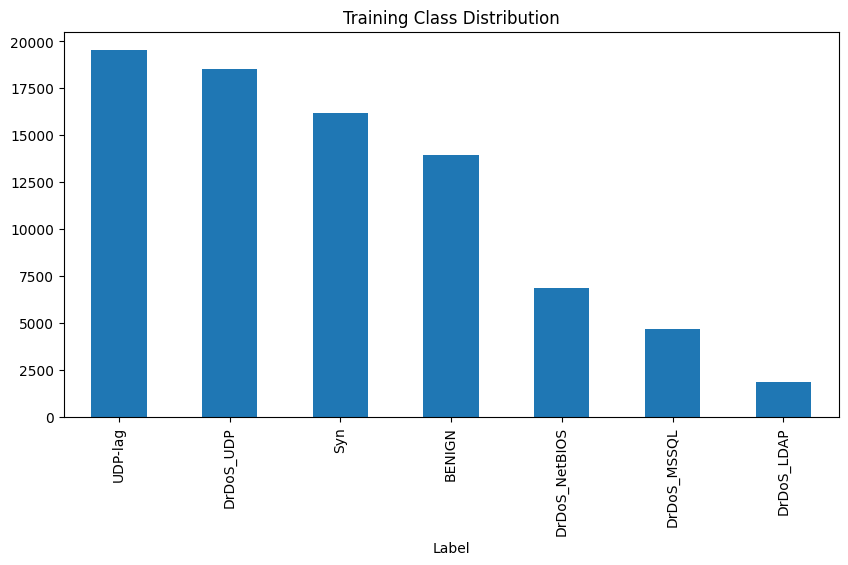

In [ ]:
train_7_classes['Label'].value_counts().plot(
    kind='bar',
    figsize=(10,5),
    title='Training Class Distribution'
)

## 💾 Exportation des datasets finaux

Les datasets prétraités sont exportés afin d’être utilisés lors des phases d’entraînement et d’évaluation des modèles de Machine Learning et Deep Learning.

In [ ]:
# Export final processed datasets
train_7_classes.to_csv(
    'dataset_7_classes.csv',
    index=False
)

test_7_classes.to_csv(
    'test_7_classes.csv',
    index=False
)

print("Datasets exported successfully.")

Datasets exported successfully.


## 🏷️ Préparation des données pour le Machine Learning

Cette section prépare les données pour l'entraînement des modèles de Machine Learning et Deep Learning.

Les étapes incluent :
- la séparation des features et labels
- la normalisation des données
- l'encodage des labels
- la gestion du déséquilibre des classes avec SMOTE

### 🔹 Séparation des features et labels

In [ ]:
# Features (X) and target labels (y)

X_train = train_7_classes.drop(columns=['Label'])
y_train = train_7_classes['Label']

X_test = test_7_classes.drop(columns=['Label'])
y_test = test_7_classes['Label']

# Vérification des dimensions
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (81590, 27)
Test set shape: (40568, 27)


### 🔹 Encodage des labels

In [ ]:
# Encode categorical labels into numerical values
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Display class mapping
print("Class mapping:")
print(dict(zip(label_encoder.classes_,
               label_encoder.transform(label_encoder.classes_))))

Class mapping:
{'BENIGN': np.int64(0), 'DrDoS_LDAP': np.int64(1), 'DrDoS_MSSQL': np.int64(2), 'DrDoS_NetBIOS': np.int64(3), 'DrDoS_UDP': np.int64(4), 'Syn': np.int64(5), 'UDP-lag': np.int64(6)}


### 🔹 Normalisation des caractéristiques

In [ ]:
# Standardize numerical features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features normalized successfully.")

Features normalized successfully.


### ⚖️ Gestion du déséquilibre des classes avec SMOTE

SMOTE est appliqué uniquement aux données d'entraînement afin d'éviter les fuites de données (data leakage) et d'améliorer l'équilibre des classes.

In [ ]:
# Apply SMOTE only on training data
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_scaled,
    y_train_encoded
)

print("SMOTE applied successfully.")

SMOTE applied successfully.


### 🔹 Vérification des données après SMOTE

In [ ]:
# Dataset dimensions after SMOTE
print("Dimensions after SMOTE:")
print(f"X_train_resampled : {X_train_resampled.shape}")
print(f"y_train_resampled : {y_train_resampled.shape}")

# Final test dataset dimensions
print(f"X_test_scaled : {X_test_scaled.shape}")
print(f"y_test_encoded : {y_test_encoded.shape}")

Dimensions after SMOTE:
X_train_resampled : (136787, 27)
y_train_resampled : (136787,)
X_test_scaled : (40568, 27)
y_test_encoded : (40568,)


### 🔹 Répartition des classes après rééquilibrage

In [ ]:
# Check class distribution after SMOTE
unique, counts = np.unique(y_train_resampled, return_counts=True)

print("Class distribution after SMOTE:")
print(dict(zip(unique, counts)))

Class distribution after SMOTE:
{np.int64(0): np.int64(19541), np.int64(1): np.int64(19541), np.int64(2): np.int64(19541), np.int64(3): np.int64(19541), np.int64(4): np.int64(19541), np.int64(5): np.int64(19541), np.int64(6): np.int64(19541)}


<Axes: >

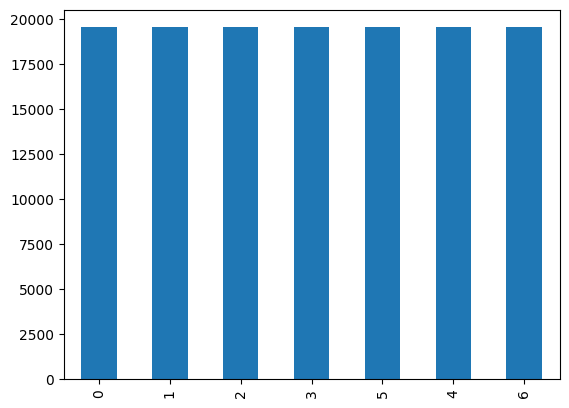

In [ ]:
pd.Series(y_train_resampled).value_counts().plot(kind='bar')

In [ ]:
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoder, 'label_encoder.pkl')

['label_encoder.pkl']

In [ ]:
np.save('X_train.npy', X_train_resampled)
np.save('y_train.npy', y_train_resampled)

np.save('X_test.npy', X_test_scaled)
np.save('y_test.npy', y_test_encoded)

## ✅ Résumé du prétraitement

Le dataset a été nettoyé, normalisé et préparé pour l’entraînement des modèles de Machine Learning et Deep Learning utilisés dans le système de détection d’intrusion réseau.